# House Price Prediction

Working out what a flat or house in India is worth, from a Kaggle file of 187,531 real listings.
This notebook loads the data, figures out what is actually in it, cleans it, has a look around,
trains a few models and exports the best one for the FastAPI service in `backend/`.

Runs top to bottom with **Kernel > Restart & Run All**. Nothing here depends on cells being run
out of order.

## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# The cleaning functions are a package at the repository root, not cells in this
# notebook, because backend/ imports the same ones. Cleaning that lived only
# here would drift away from what the service does the first time either changed.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from house_price.cleaning import (  # noqa: E402
    CATEGORICAL_FEATURES,
    NUMERIC_FEATURES,
    build_frame,
    percentile,
)
from house_price.model import ClippedRegressor  # noqa: E402

DATA = ROOT / "notebooks" / "data" / "house_prices.csv"
MODELS = ROOT / "models"
FIGURES = ROOT / "reports"
MODELS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42


def rupees(v: float) -> str:
    """Format a rupee amount the way the listings write it."""
    if abs(v) >= 1e7:
        return f"{v / 1e7:.2f} Cr"
    if abs(v) >= 1e5:
        return f"{v / 1e5:.2f} Lac"
    return f"{v:.0f}"


print("pandas", pd.__version__, "| numpy", np.__version__)
import sklearn
print("scikit-learn", sklearn.__version__)

pandas 3.0.5 | numpy 2.5.2
scikit-learn 1.9.0


## 1. Load and inspect

First job is finding out what the columns really hold. Three of the decisions further down came
from this table not matching what the column names suggest.

In [2]:
raw = pd.read_csv(DATA, low_memory=False)
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(3)

187,531 rows x 21 columns


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN


In [3]:
profile = pd.DataFrame(
    {
        "missing %": (raw.isna() | raw.astype(str).apply(lambda c: c.str.strip() == "")).mean() * 100,
        "distinct": raw.nunique(dropna=False),
        "example": [raw[c].dropna().astype(str).str.strip().replace("", None).dropna().iloc[0][:38]
                    if raw[c].notna().any() else "" for c in raw.columns],
    }
)
profile.round(1)

,missing %,distinct,example
Index,0.0,187531,0
Title,0.0,32446,1 BHK Ready to Occupy Flat for sale in
Description,1.6,65635,"Bhiwandi, Thane has an attractive 1 BH"
Amount(in rupees),0.0,1561,42 Lac
Price (in rupees),9.4,10959,6000.0
location,0.0,81,thane
Carpet Area,43.0,2759,500 sqft
Status,0.3,2,Ready to Move
Floor,3.8,948,10 out of 11
Transaction,0.0,5,Resale


In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [5]:
# Only 3 of the 21 columns are numeric, which is the whole problem with this file.
raw.describe(include="all").T[["count", "unique", "top", "freq"]].head(21)

,count,unique,top,freq
Index,187531.0,NaN,NaN,NaN
Title,187531,32446,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106
Description,184508,65634,Multistorey apartment is available for sale. I...,2732
Amount(in rupees),187531,1561,Call for Price,9684
Price (in rupees),169866.0,NaN,NaN,NaN
location,187531,81,new-delhi,27599
Carpet Area,106858,2758,1000 sqft,5285
Status,186916,1,Ready to Move,186916
Floor,180454,947,2 out of 4,12433
Transaction,187448,4,Resale,144172


### So, answering the obvious questions

**How many rows?** 187,531 rows and 21 columns.

**Which are numeric and which are text?** Basically all of it is text. `raw.info()` shows only
`Index` as a real number. Even the price and the areas come through as objects, because they hold
things like `"42 Lac"` and `"1200 sqft"`. That's what section 2 is for.

**Which columns are missing the most?** `Dimensions` and `Plot Area` are 100% blank so they're
useless. Then `Society` at 58%, `Super Area` at 57%, `Car Parking` at 55%, `overlooking` at 43% and
`Carpet Area` at 43%.

### Three things that table contradicts

**1. `location` is a city, not a neighbourhood.** 81 distinct values across 187k rows.

**2. `Price (in rupees)` is not the price.** Its values are in the thousands while
`Amount(in rupees)` says `42 Lac`. It's the rate per square foot, so using it as a feature would
leak the answer, since rate x area is the price. Left out.

**3. `Dimensions`, `Plot Area` and `Status` are useless.** The first two are always blank and
`Status` says the same thing in every row that isn't.

In [6]:
print("location distinct:", raw["location"].nunique(), "->", list(raw["location"].dropna().unique()[:6]))
print()
print("Amount(in rupees) :", list(raw["Amount(in rupees)"].dropna().unique()[:4]))
print("Price (in rupees) :", list(raw["Price (in rupees)"].dropna().unique()[:4]), "<- a rate, not a price")
print()
for col in ["Dimensions", "Plot Area", "Status"]:
    values = raw[col].dropna().astype(str).str.strip()
    values = values[values != ""]
    print(f"{col:12s} non-blank rows: {len(values):>6,}   distinct values: {values.nunique()}")

location distinct: 81 -> ['thane', 'navi-mumbai', 'nagpur', 'mumbai', 'ahmedabad', 'bangalore']

Amount(in rupees) : ['42 Lac ', '98 Lac ', '1.40 Cr ', '25 Lac ']
Price (in rupees) : [np.float64(6000.0), np.float64(13799.0), np.float64(17500.0), np.float64(18824.0)] <- a rate, not a price

Dimensions   non-blank rows:      0   distinct values: 0
Plot Area    non-blank rows:      0   distinct values: 0
Status       non-blank rows: 186,916   distinct values: 1


## 2. Cleaning and feature engineering

All the parsers live in `house_price/cleaning.py`. What each column needed:

- **Price is text.** `"42 Lac"`, `"1.40 Cr"`, `"Call for Price"`. 1 Lac is 100,000 and 1 Cr is
  10,000,000. The "Call for Price" rows have no target so they go rather than get guessed.
- **Areas are text, in ten units.** `sqft`, `sqyrd`, `sqm`, and a tail of `marla`, `kanal`,
  `bigha`, `acre`. All converted to square feet. An unknown unit returns nothing instead of a
  wrong number.
- **Two area columns and both are mostly empty.** Carpet is there 43% of the time, super area 57%.
  Carpet is the honest measurement so it wins when both exist, and an `is_carpet_area` flag tells
  the model which one it got. Super area is always bigger, so without the flag that just looks
  like noise.
- **`Floor` is `"3 out of 10"`** with `Ground` as 0 and basements negative. Split into the storey
  and the building height, plus a `floor_ratio`.
- **`Bathroom` and `Balcony` sometimes say `"> 10"`**, which becomes 11.
- **`Car Parking` is `"1 Covered"`, `"2 Open"`, and sometimes `"1 Covered,"`** with a trailing
  comma. Split into a count and a covered flag.
- **`overlooking` is a set, not a category.** Three facts in random order make 20 different
  strings, so it becomes three yes/no features.
- **`facing` spells one direction two ways** (`"South - West"` and `"South -West"`).
- **Missing values get their own category** for `facing` and `Ownership`. They're 37% and 35% of
  the file, too much to throw away, and not knowing is probably informative anyway.

In [7]:
df, log = build_frame(raw)
funnel = pd.DataFrame(log.as_rows(), columns=["step", "rows"])
funnel

,step,rows
0,raw,187531
1,dropped: no usable price,-9684
2,dropped: no usable area,-90
3,dropped: duplicate listings,-113886
4,dropped: price-per-sqft outliers,-1225
5,kept,62646


### The dataset is mostly duplicates

This is the thing that caught me out. **Three fifths of the file is repeat listings.** One advert
shows up 821 times. Split at random without noticing and the same listing ends up in both train and
test, so the test set is only checking what the model remembers.

So the duplicates go before the split. Two rows count as the same listing when every feature the
model sees and the price match. `Index` and the free text columns aren't part of that, since they
differ between copies of what is obviously one advert. Section 5 puts a number on what this was
worth.

In [8]:
key = ["Title", "location", "Amount(in rupees)", "Carpet Area", "Super Area", "Floor", "Society"]
repeats = raw.groupby(key, dropna=False).size().sort_values(ascending=False)
print(f"{log.duplicates:,} of {log.total:,} rows dropped as duplicates "
      f"({100 * log.duplicates / log.total:.0f}%)")
print(f"most repeated advertisement appears {repeats.iloc[0]} times:")
print(" ", repeats.index[0][0][:90])
print(f"\nkept {len(df):,} distinct listings")

113,886 of 187,531 rows dropped as duplicates (61%)
most repeated advertisement appears 821 times:
  3 BHK Ready to Occupy Flat for sale Laxmi Nagar

kept 62,646 distinct listings


## 3. Exploratory data analysis

### 3.1 The target is heavily skewed

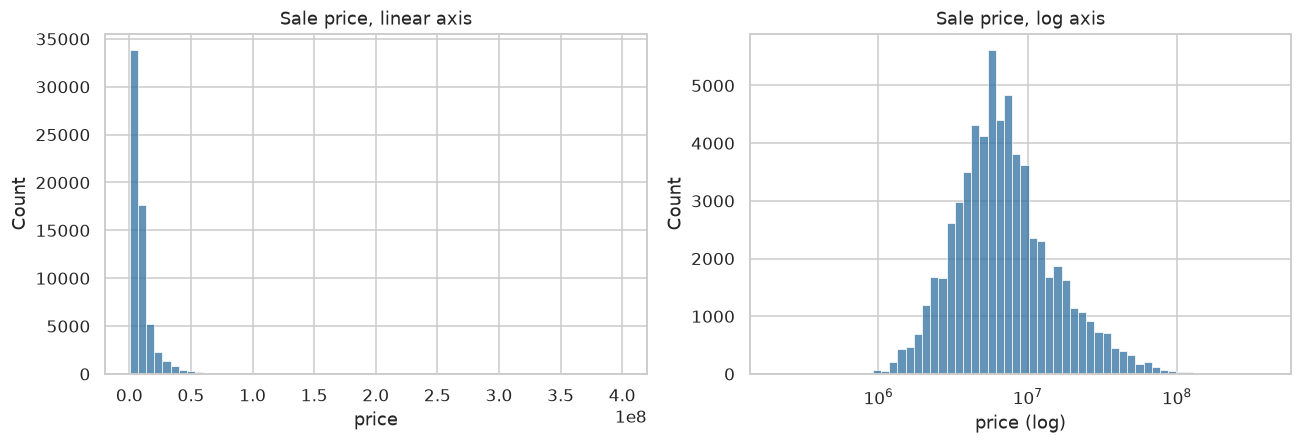

  p1   15.00 Lac
  p25  42.00 Lac
  p50  65.00 Lac
  p75  1.06 Cr
  p99  5.70 Cr

  mean / median = 1.51x  <- that ratio is the skew


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(df["price"], bins=60, ax=axes[0], color="#2f6f9f")
axes[0].set_title("Sale price, linear axis")
axes[0].set_xlabel("price")
sns.histplot(df["price"], bins=60, log_scale=True, ax=axes[1], color="#2f6f9f")
axes[1].set_title("Sale price, log axis")
axes[1].set_xlabel("price (log)")
plt.tight_layout()
plt.savefig(FIGURES / "01_price_distribution.png", bbox_inches="tight")
plt.show()

q = np.sort(df["price"].to_numpy())
for p in (1, 25, 50, 75, 99):
    print(f"  p{p:<3d} {rupees(percentile(q, p))}")
print(f"\n  mean / median = {df['price'].mean() / df['price'].median():.2f}x  <- that ratio is the skew")

Left panel is one bar squashed against the y axis, right panel is nearly symmetric. That's the
whole argument for training on **log price**, and section 5 measures what it's worth.

### 3.2 Price against floor area

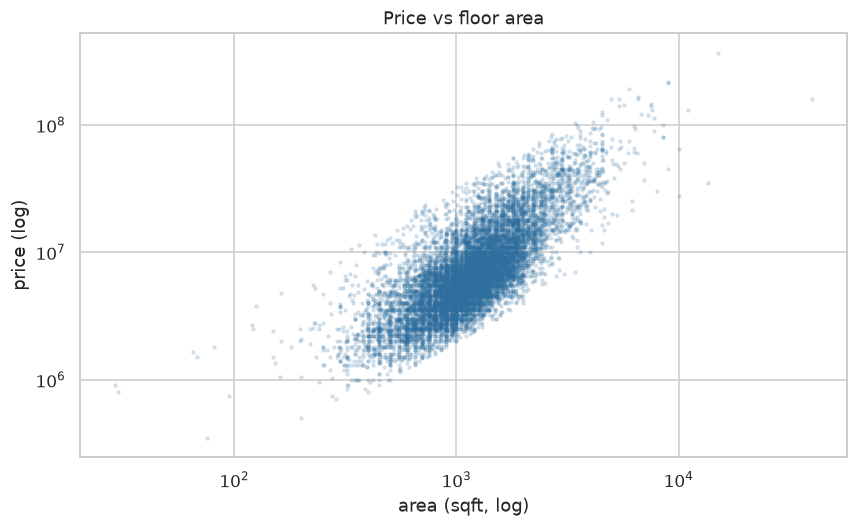

correlation of log(area) with log(price): r = 0.755


In [10]:
sample = df.sample(min(12_000, len(df)), random_state=RANDOM_STATE)
fig, ax = plt.subplots()
ax.scatter(sample["area_sqft"], sample["price"], s=4, alpha=0.15, color="#2f6f9f")
ax.set(xscale="log", yscale="log", xlabel="area (sqft, log)", ylabel="price (log)",
       title="Price vs floor area")
plt.savefig(FIGURES / "02_price_vs_area.png", bbox_inches="tight")
plt.show()

r = np.corrcoef(np.log(df["area_sqft"]), np.log(df["price"]))[0, 1]
print(f"correlation of log(area) with log(price): r = {r:.3f}")

A straight line on a log-log plot means a power law, so area goes into the model as `log(area)`
rather than raw square feet. The vertical banding is real, people list on round numbers like 1000
and 1200 sqft.

### 3.3 Where the listings are

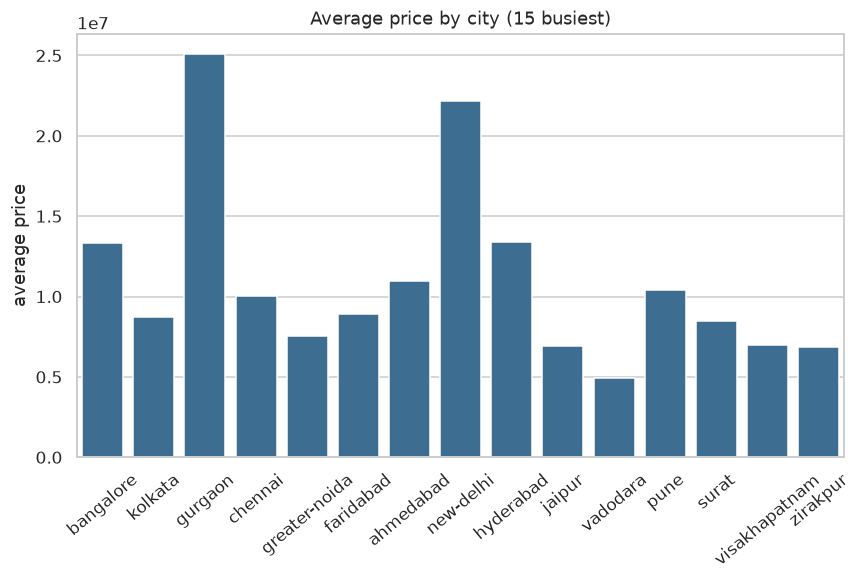

,listings,mean,median
location,,,
bangalore,2874,1.33 Cr,85.00 Lac
kolkata,2835,87.24 Lac,52.00 Lac
gurgaon,2831,2.51 Cr,1.98 Cr
chennai,2828,1.00 Cr,67.00 Lac
greater-noida,2808,75.19 Lac,62.05 Lac
faridabad,2799,88.96 Lac,75.00 Lac
ahmedabad,2798,1.10 Cr,70.00 Lac
new-delhi,2669,2.22 Cr,1.60 Cr
hyderabad,2646,1.34 Cr,90.00 Lac


5.0x spread in median price on city alone
(mean is plotted, median is in the table. The mean runs higher because of the expensive tail.)


In [11]:
top = df["location"].value_counts().head(15).index
by_city = (df[df["location"].isin(top)].groupby("location")["price"]
           .agg(listings="size", mean="mean", median="median").sort_values("listings", ascending=False))

fig, ax = plt.subplots()
sns.barplot(x=by_city.index, y=by_city["mean"], ax=ax, color="#2f6f9f")
ax.set(title="Average price by city (15 busiest)", xlabel="", ylabel="average price")
ax.tick_params(axis="x", rotation=40)
plt.savefig(FIGURES / "03_price_by_location.png", bbox_inches="tight")
plt.show()

display(by_city.assign(mean=by_city["mean"].map(rupees), median=by_city["median"].map(rupees)))
spread = by_city["median"].max() / by_city["median"].min()
print(f"{spread:.1f}x spread in median price on city alone")
print("(mean is plotted, median is in the table. The mean runs higher because of the expensive tail.)")

### 3.4 Furnishing and bathrooms

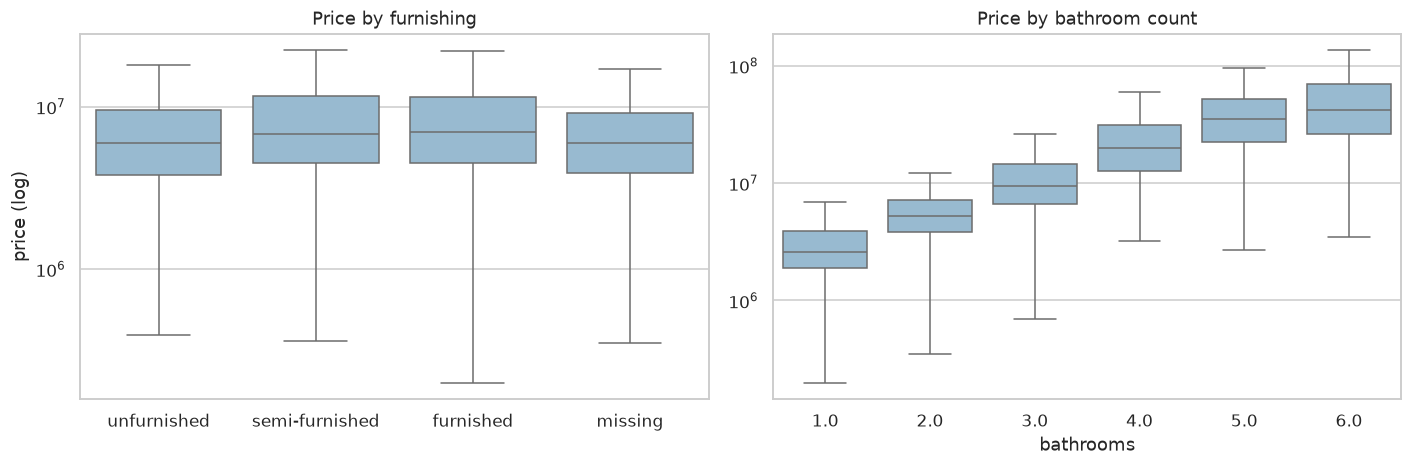

furnishing
furnished         70.00 Lac
missing           60.00 Lac
semi-furnished    68.00 Lac
unfurnished       59.60 Lac


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
sns.boxplot(data=df, x="furnishing", y="price", ax=axes[0], color="#8fbcd9", showfliers=False)
axes[0].set(yscale="log", title="Price by furnishing", xlabel="", ylabel="price (log)")

baths = df[df["bathroom"].between(1, 6)]
sns.boxplot(data=baths, x="bathroom", y="price", ax=axes[1], color="#8fbcd9", showfliers=False)
axes[1].set(yscale="log", title="Price by bathroom count", xlabel="bathrooms", ylabel="")
plt.tight_layout()
plt.savefig(FIGURES / "04_price_by_furnishing_and_bathroom.png", bbox_inches="tight")
plt.show()

print(df.groupby("furnishing")["price"].median().map(rupees).to_string())

The furnishing boxes overlap a lot, so it shifts the price but nowhere near decides it. Bathroom
count separates things much more cleanly, since it's a proxy for size and segment at the same
time.

## 4. Features and split

62,646 rows left, split 80/20 with a fixed seed. The scaling, the medians used for missing values
and the one-hot vocabularies are all fitted **inside the pipeline**, which means they only ever see
the training fold. `Pipeline.fit` never touches the test set. Fitting them on everything would leak
test data into the preprocessing and inflate every number in section 5.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"train {len(X_train):,}  test {len(X_test):,}")

preprocessor = ColumnTransformer(
    [
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), NUMERIC_FEATURES),
        # min_frequency keeps the top locations and folds the long tail into one
        # column; handle_unknown="infrequent_if_exist" then sends a city the model
        # never saw to that same column instead of failing at inference time.
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                                   min_frequency=30,
                                                   sparse_output=False))]), CATEGORICAL_FEATURES),
    ]
)
width = preprocessor.fit(X_train).transform(X_train.head(1)).shape[1]
print(f"encoded width: {width} features "
      f"({len(NUMERIC_FEATURES)} numeric + {width - len(NUMERIC_FEATURES)} one-hot)")

train 50,116  test 12,530


encoded width: 110 features (12 numeric + 98 one-hot)


## 5. Models

Four estimators plus a no-model baseline. They're all wrapped in
`TransformedTargetRegressor(func=np.log1p, inverse_func=np.expm1)` so they train on log price and
predict rupees. That also means the exported pickle takes raw features and gives back a price, with
no manual `expm1` for the API to forget about.

In [14]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.neural_network import MLPRegressor


def scores(actual, predicted) -> dict[str, float]:
    """MAE, RMSE and R2 in rupees, plus the median absolute percentage error."""
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": root_mean_squared_error(actual, predicted),
        "R2": r2_score(actual, predicted),
        "MdAPE": float(np.median(np.abs((actual - predicted) / actual)) * 100),
    }


def build(estimator, log_target: bool = True):
    """Preprocessing + estimator, trained on log price, clipped to the seen range.

    ClippedRegressor is the outer layer so the clip is applied in rupees, after
    expm1 has undone the log. See section 5.1 for why it is not optional.
    """
    pipe = Pipeline([("prep", preprocessor), ("reg", estimator)])
    if not log_target:
        # The brief asks to try both and report the difference, so this one
        # trains straight on rupees.
        return ClippedRegressor(pipe)
    logged = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    return ClippedRegressor(logged)


def artifact_mb(model) -> float:
    """Size of the pickle this model would export, in MB."""
    import io

    buffer = io.BytesIO()
    joblib.dump(model, buffer)
    return buffer.getbuffer().nbytes / 1e6


candidates = {
    "Linear regression": build(LinearRegression()),
    "MLP 128-64": build(MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=60,
                                     early_stopping=True, n_iter_no_change=8,
                                     random_state=RANDOM_STATE)),
    "Random forest": build(RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                                                 n_jobs=-1, random_state=RANDOM_STATE)),
    "Gradient boosting": build(HistGradientBoostingRegressor(max_iter=400,
                                                             random_state=RANDOM_STATE)),
    "Gradient boosting, raw target": build(
        HistGradientBoostingRegressor(max_iter=400, random_state=RANDOM_STATE),
        log_target=False,
    ),
}

results = {}
fitted = {}
for name, model in candidates.items():
    started = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - started
    results[name] = scores(y_test.to_numpy(), model.predict(X_test)) | {
        "fit (s)": elapsed,
        "pickle (MB)": artifact_mb(model),
    }
    fitted[name] = model
    r = results[name]
    print(f"{name:<20s} {elapsed:6.1f}s  MdAPE {r['MdAPE']:5.1f}%  R2 {r['R2']:.3f}  {r['pickle (MB)']:7.1f} MB")

Linear regression       1.1s  MdAPE  20.6%  R2 0.745      0.0 MB


MLP 128-64             38.9s  MdAPE  19.5%  R2 0.744      0.6 MB


Random forest          19.3s  MdAPE  17.3%  R2 0.826    393.7 MB


Gradient boosting       3.5s  MdAPE  17.5%  R2 0.831      1.5 MB


Gradient boosting, raw target    1.8s  MdAPE  20.1%  R2 0.821      0.6 MB


### 5.1 Why predictions get clipped

Training on `log1p(price)` and undoing it with `expm1` turns a small error in log space into a huge
one in rupees at the top of the range. Without clipping, **one** test row out of 12,530 came back
at 300 Cr when the actual price was 16 Cr, and that single prediction dragged the MLP's R2 from
0.744 to **-3.638**. One row deciding the headline metric while the median error stayed at a
perfectly fine 19.5%.

`ClippedRegressor` caps every prediction to the price range seen while fitting. The model has no
business predicting eight times more than anything it was ever shown, and this stops one blown up
outlier speaking for the whole thing. It's inside the exported pipeline so the API gets it too.

### The baseline that actually matters

What an agent would guess without any model: the city's median price per square foot times the
floor area. Beating the linear model means the network found interactions. Beating **this** means
the whole pipeline was worth building.

In [15]:
rates = df.loc[X_train.index].assign(price=y_train)
rates["ppsf"] = rates["price"] / np.expm1(rates["log_area_sqft"])
city_rate = rates.groupby("location")["ppsf"].median()
overall_rate = rates["ppsf"].median()

test_area = np.expm1(X_test["log_area_sqft"])
rate_card = X_test["location"].map(city_rate).fillna(overall_rate) * test_area
results["Rate card (no model)"] = scores(y_test.to_numpy(), rate_card.to_numpy()) | {
    "fit (s)": 0.0, "pickle (MB)": 0.0
}

table = pd.DataFrame(results).T.sort_values("MdAPE")
display(table.assign(
    MAE=lambda t: t["MAE"].map(rupees),
    RMSE=lambda t: t["RMSE"].map(rupees),
    R2=lambda t: t["R2"].round(3),
    MdAPE=lambda t: t["MdAPE"].round(1),
    **{"fit (s)": lambda t: t["fit (s)"].round(1),
       "pickle (MB)": lambda t: t["pickle (MB)"].round(1)},
))

# Selection rule, decided before looking at the numbers: best MdAPE wins, but a
# model within half a percentage point of the best is treated as tied, and the
# smallest artifact among those ties takes it. Accuracy that costs hundreds of
# megabytes to ship is not accuracy worth having, and the repository cannot
# carry a model it has to exclude from version control.
trained = table.drop(index="Rate card (no model)")
best = trained["MdAPE"].min()
ties = trained[trained["MdAPE"] <= best + 0.5]
winner_name = ties["pickle (MB)"].idxmin()
winner = fitted[winner_name]

print(f"within 0.5pp of the best: {list(ties.index)}")
print(f"winner: {winner_name} "
      f"(MdAPE {results[winner_name]['MdAPE']:.1f}%, {results[winner_name]['pickle (MB)']:.1f} MB)")

,MAE,RMSE,R2,MdAPE,fit (s),pickle (MB)
Random forest,23.64 Lac,50.53 Lac,0.826,17.3,19.3,393.7
Gradient boosting,23.01 Lac,49.72 Lac,0.831,17.5,3.5,1.5
MLP 128-64,25.98 Lac,61.26 Lac,0.744,19.5,38.9,0.6
"Gradient boosting, raw target",24.76 Lac,51.16 Lac,0.821,20.1,1.8,0.6
Linear regression,27.15 Lac,61.05 Lac,0.745,20.6,1.1,0.0
Rate card (no model),32.41 Lac,71.87 Lac,0.647,24.1,0.0,0.0


within 0.5pp of the best: ['Random forest', 'Gradient boosting']
winner: Gradient boosting (MdAPE 17.5%, 1.5 MB)


### Log price vs raw price

The brief suggests training on `log1p(price)` and inverting with `expm1`, and trying both. Same
estimator, same seed, the only difference is what it predicts.

In [16]:
log_run = results["Gradient boosting"]
raw_run = results["Gradient boosting, raw target"]

print(f"{'':<22} {'MdAPE':>8} {'R2':>8} {'MAE':>14}")
for label, r in (("log1p target", log_run), ("raw target", raw_run)):
    print(f"{label:<22} {r['MdAPE']:>7.1f}% {r['R2']:>8.3f} {rupees(r['MAE']):>14}")

gap = raw_run["MdAPE"] - log_run["MdAPE"]
print(f"\nlog target is {gap:.1f} percentage points better on MdAPE.")
print("Squared error on raw rupees is dominated by the expensive listings, so the raw model")
print("spends its capacity there and gets worse at everything else.")

                          MdAPE       R2            MAE
log1p target              17.5%    0.831      23.01 Lac
raw target                20.1%    0.821      24.76 Lac

log target is 2.5 percentage points better on MdAPE.
Squared error on raw rupees is dominated by the expensive listings, so the raw model
spends its capacity there and gets worse at everything else.


### The tip has a bias in it

The log target does help, so the brief is right about that. But `log1p` then `expm1` doesn't
actually round-trip the way it looks like it does, and the brief doesn't mention it.

Least squares in log space fits `E[log y | x]`, the mean of the log. Exponentiating that gives you
the **median** of y back, not the mean, because `exp` is convex and Jensen's inequality says
`exp(E[log y]) <= E[y]`. So every prediction lands systematically low, and training longer doesn't
fix it because the model is doing exactly what it was asked to do.

Duan's smearing estimator (1983) is the standard fix. Take the training residuals in log space,
average `exp` of them, and scale by that:

`S = mean(exp(log y_i - f(x_i)))`, then predict `expm1(f(x) + log S)`.

There's also a parametric version, `exp(sigma^2 / 2)`, which assumes the residuals are lognormal.
If the two agree, the residuals really are close to lognormal.

In [17]:
from house_price.model import SmearedRegressor

# Fit on log price the way the brief describes, then look at the residuals.
plain = Pipeline([("prep", preprocessor),
                  ("reg", HistGradientBoostingRegressor(max_iter=400, random_state=RANDOM_STATE))])
plain.fit(X_train, np.log1p(y_train))

residuals = np.log1p(y_train.to_numpy()) - plain.predict(X_train)
smearing = float(np.mean(np.exp(residuals)))
sigma2 = float(np.var(residuals))

log_pred = plain.predict(X_test)
variants = {
    "the tip as written": np.expm1(log_pred),
    "Duan smearing": np.expm1(log_pred + np.log(smearing)),
    "parametric, exp(sigma^2/2)": np.expm1(log_pred + sigma2 / 2),
}

print(f"smearing factor S = {smearing:.4f}, exp(sigma^2/2) = {np.exp(sigma2 / 2):.4f}")
print("they agree, so the residuals are close to lognormal\n")

actual = y_test.to_numpy()
bias = pd.DataFrame(
    {name: scores(actual, p) | {"total vs actual": p.sum() / actual.sum()}
     for name, p in variants.items()}
).T
display(bias.round({"MAE": 0, "RMSE": 0, "R2": 3, "MdAPE": 1, "total vs actual": 3}))

smearing factor S = 1.0382, exp(sigma^2/2) = 1.0370
they agree, so the residuals are close to lognormal



,MAE,RMSE,R2,MdAPE,total vs actual
the tip as written,2301157.0,4971567.0,0.831,17.5,0.953
Duan smearing,2320343.0,4917082.0,0.835,18.2,0.990
"parametric, exp(sigma^2/2)",2319139.0,4917909.0,0.835,18.2,0.989


Look at the last column. The tip's version predicts a total **4.7% under** the real total, which
is the bias showing up exactly where the theory says it will. Smearing takes it to within 1%.

The catch is that it's a trade, not a free win:

- **uncorrected** gives the conditional median, which is what minimises absolute and percentage
  error, so it wins on MAE and MdAPE
- **smeared** gives the conditional mean, which is what minimises squared error and is the only one
  that adds up correctly across a set of properties, so it wins on RMSE and R2

So the right answer depends on what you're doing. Pricing one flat, which is what the app does, the
median is the better point estimate and the uncorrected version stays. Valuing a portfolio of a
thousand flats, the uncorrected one is short by 4.7% and you want the smeared one.

`SmearedRegressor` in `house_price/model.py` implements it either way. The brief's tip isn't wrong,
it just stops one step early.

**MdAPE is the one to look at.** Prices cover two orders of magnitude, so an MAE in rupees is
dominated by a few very expensive listings. The median absolute percentage error tells you how
wrong a normal prediction is.

### What de-duplication was worth

In [18]:
# The same estimator, on the file exactly as it ships. This is the score the
# project would have reported had the duplicates been left in - a mistake that
# looks like a great result.
dup_df, _ = build_frame(raw, dedup=False)
dX = dup_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
dy = dup_df["price"]
dX_tr, dX_te, dy_tr, dy_te = train_test_split(dX, dy, test_size=0.2, random_state=RANDOM_STATE)

leaky = build(HistGradientBoostingRegressor(max_iter=400, random_state=RANDOM_STATE))
leaky.fit(dX_tr, dy_tr)
leaky_scores = scores(dy_te.to_numpy(), leaky.predict(dX_te))

display(pd.DataFrame(
    {"duplicates left in": leaky_scores, "de-duplicated (this notebook)": results[winner_name]}
).T[["MdAPE", "R2"]].round(3))

,MdAPE,R2
duplicates left in,3.359,0.929
de-duplicated (this notebook),17.513,0.831


The first row is the nicer number and the useless one. Most of its test listings are also in its
training set, so the model is just recalling prices it has already seen. The second row is what it
does on listings it has genuinely never seen.

### Predicted vs actual

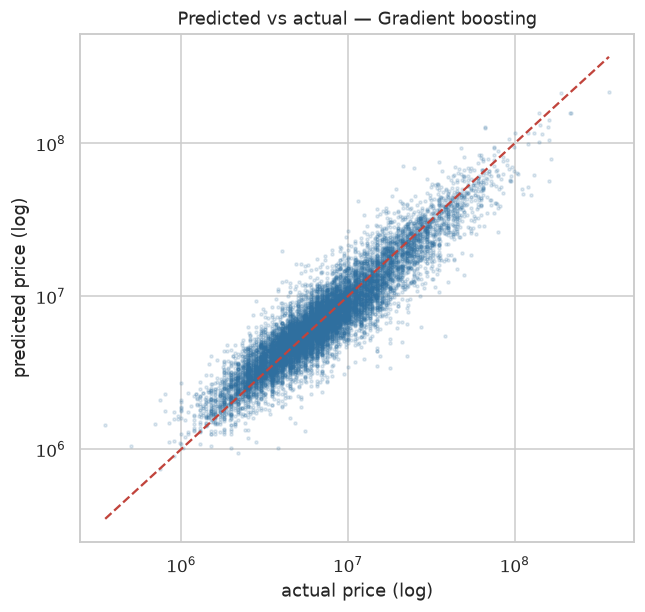

In [19]:
predicted = winner.predict(X_test)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(y_test, predicted, s=4, alpha=0.15, color="#2f6f9f")
lo, hi = y_test.min(), y_test.max()
ax.plot([lo, hi], [lo, hi], "--", color="#c1443c", lw=1.5)
ax.set(xscale="log", yscale="log", xlabel="actual price (log)", ylabel="predicted price (log)",
       title=f"Predicted vs actual — {winner_name}")
plt.savefig(FIGURES / "05_predicted_vs_actual.png", bbox_inches="tight")
plt.show()

The points sit close to the diagonal through the middle and flatten out at both ends. That's the
model pulling extremes toward the average, which is what squared error loss does.

### Bonus: 5-fold cross-validation

In [20]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2 = cross_val_score(winner, X, y, cv=cv, scoring="r2", n_jobs=-1)
print("fold R2:", np.round(cv_r2, 3))
print(f"mean {cv_r2.mean():.3f}  sd {cv_r2.std():.3f}")

fold R2: [0.835 0.794 0.812 0.806 0.831]
mean 0.816  sd 0.016


The spread across folds is small, so the single test set number above isn't a lucky split.

## 6. Export

Three files, all read by `backend/`:

- `house_price.pkl` is the whole fitted object: the preprocessing, the estimator and the target
  transform. Since a full Pipeline gets exported, the API doesn't encode anything itself.
- `locations.json` is the city list for the frontend dropdown.
- `metrics.json` is what the README quotes, so those numbers can't drift away from the run that
  produced them.

In [21]:
joblib.dump(winner, MODELS / "house_price.pkl")

locations = sorted(df["location"].unique().tolist())
(MODELS / "locations.json").write_text(json.dumps(locations, indent=2))

metrics = {
    "winner": winner_name,
    "sklearn_version": sklearn.__version__,
    "rows": {"raw": int(log.total), "kept": int(len(df)),
             "train": int(len(X_train)), "test": int(len(X_test))},
    "features": int(width),
    "test_scores": {k: {m: float(v) for m, v in s.items()} for k, s in results.items()},
    "cv_r2": {"folds": [float(v) for v in cv_r2], "mean": float(cv_r2.mean()), "sd": float(cv_r2.std())},
    "leakage_check": {k: float(v) for k, v in leaky_scores.items()},
}
(MODELS / "metrics.json").write_text(json.dumps(metrics, indent=2))

# Sanity check: reload and predict, the way the service will.
reloaded = joblib.load(MODELS / "house_price.pkl")
sample = X_test.head(1)
assert np.allclose(reloaded.predict(sample), winner.predict(sample))
print(f"reloaded prediction: {rupees(float(reloaded.predict(sample)[0]))}  (identical after a round trip)")
print(f"exported {winner_name} + {len(locations)} locations to models/")

reloaded prediction: 1.33 Cr  (identical after a round trip)
exported Gradient boosting + 81 locations to models/


## 7. Conclusion

| | MdAPE | R2 | what it knows |
|---|---|---|---|
| Rate card | 24.1% | 0.647 | city and area, no model |
| Linear regression | 20.6% | 0.745 | all the features, no interactions |
| Gradient boosting | 17.5% | 0.831 | same features, with interactions |

**For what it's given, it works.** It cuts the no-model rate card's error by about a quarter, and
roughly half of that comes from the cleaning and encoding rather than the estimator, since the
linear model on the same features already closes part of the gap.

**In absolute terms it's still loose, and that's the data not the model.** The limit is `location`,
which is a city, and in Indian property the neighbourhood is what matters. Two 1,000 sqft flats in
Mumbai can differ 3x between Bandra and Bhiwandi and nothing in the features separates them, so
that variance just isn't learnable here.

The neighbourhood isn't actually missing from the file though. It's in `Title` ("for sale in
Punjabi Bagh East") and `Description`, neither of which I use. Pulling the locality and the BHK
count out of that text is the obvious next thing, and it's a text parsing job rather than a
modelling one.